In [2]:
import requests
import pandas as pd
import io

def descargar_zona_cuadricula(fecha_inicio, fecha_fin, mag_min, min_lat, max_lat, min_lon, max_lon):
    url = "https://earthquake.usgs.gov/fdsnws/event/1/query"
    params = {
        "format": "csv",
        "starttime": fecha_inicio,
        "endtime": fecha_fin,
        "minmagnitude": mag_min,
        # Filtros geográficos:
        "minlatitude": min_lat,
        "maxlatitude": max_lat,
        "minlongitude": min_lon,
        "maxlongitude": max_lon
    }
    
    response = requests.get(url, params=params)
    if response.status_code == 200:
        return pd.read_csv(io.StringIO(response.text))
    else:
        print(f"Error: {response.status_code}")
        return None

In [3]:
import time
# Definimos las coordenadas de la cuadrícula de California
min_lat_california = 32.0
max_lat_california = 42.5
min_lon_california = -125.0
max_lon_california = -114.0

# Usamos la magia de Pandas para crear una lista de fechas mes a mes
# MS significa "Month Start" (Inicio de mes)
fechas = pd.date_range(start="2000-01-01", end="2024-01-01", freq="MS")

lista_df = []

print("Iniciando extracción mes a mes...")

# Bucle sobre los meses
for i in range(len(fechas) - 1):
    inicio = fechas[i].strftime("%Y-%m-%d")
    fin = fechas[i+1].strftime("%Y-%m-%d")
    
    print(f"Descargando {inicio} a {fin}...", end=" ")
    
    df_mes = descargar_zona_cuadricula(
        inicio, fin, 2.5, 
        min_lat_california, max_lat_california, 
        min_lon_california, max_lon_california
    )
    
    if df_mes is not None:
        print(f"{len(df_mes)} sismos.")
        lista_df.append(df_mes)
        
    # Pausa de 0.5 segundos para respetar los servidores del USGS
    time.sleep(0.5)

# Unir todo el catálogo si se han descargado datos
if lista_df:
    df_california_total = pd.concat(lista_df, ignore_index=True)
    
    # Por seguridad, eliminamos duplicados (si un sismo cayó exactamente a las 00:00:00 del día de corte)
    df_california_total = df_california_total.drop_duplicates(subset='id')
    
    # Ordenamos de más antiguo a más reciente
    df_california_total = df_california_total.sort_values(by='time').reset_index(drop=True)
    
    print(f"\n¡Éxito Total! Se han descargado y unificado {len(df_california_total)} sismos de California.")
    
    # Guardar en CSV para tu TFM
    df_california_total.to_csv("catalogo_california_2000_2023.csv", index=False)

Iniciando extracción mes a mes...
Descargando 2000-01-01 a 2000-02-01... 154 sismos.
Descargando 2000-02-01 a 2000-03-01... 101 sismos.
Descargando 2000-03-01 a 2000-04-01... 132 sismos.
Descargando 2000-04-01 a 2000-05-01... 125 sismos.
Descargando 2000-05-01 a 2000-06-01... 173 sismos.
Descargando 2000-06-01 a 2000-07-01... 144 sismos.
Descargando 2000-07-01 a 2000-08-01... 91 sismos.
Descargando 2000-08-01 a 2000-09-01... 87 sismos.
Descargando 2000-09-01 a 2000-10-01... 113 sismos.
Descargando 2000-10-01 a 2000-11-01... 93 sismos.
Descargando 2000-11-01 a 2000-12-01... 97 sismos.
Descargando 2000-12-01 a 2001-01-01... 125 sismos.
Descargando 2001-01-01 a 2001-02-01... 81 sismos.
Descargando 2001-02-01 a 2001-03-01... 99 sismos.
Descargando 2001-03-01 a 2001-04-01... 88 sismos.
Descargando 2001-04-01 a 2001-05-01... 148 sismos.
Descargando 2001-05-01 a 2001-06-01... 120 sismos.
Descargando 2001-06-01 a 2001-07-01... 97 sismos.
Descargando 2001-07-01 a 2001-08-01... 255 sismos.
Desca

In [3]:
df_california_total = pd.read_csv("catalogo_california_2000_2023.csv")

In [4]:
df_california_total.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2000-01-01T03:58:39.500Z,34.801000,-116.287000,5.414,3.04,ml,0.0,48.3,NaN,0.163,...,2016-04-02T00:50:27.739Z,"15km NW of Ludlow, CA",earthquake,NaN,0.641,NaN,187.0,reviewed,ci,ci
1,2000-01-01T06:08:31.150Z,34.371667,-116.137333,2.946,2.64,ml,38.0,56.0,NaN,0.200,...,2016-04-02T01:33:11.411Z,"27km NNW of Twentynine Palms, CA",earthquake,0.29,0.540,0.191,57.0,reviewed,ci,ci
2,2000-01-02T15:49:40.650Z,38.038333,-118.696000,-0.903,3.11,md,51.0,107.0,0.2252,0.060,...,2018-04-24T22:21:49.943Z,"31 km NW of Benton, California",earthquake,0.20,6.580,0.180,73.0,reviewed,nc,nc
3,2000-01-02T16:35:49.290Z,38.039000,-118.697333,4.787,2.56,md,50.0,107.0,0.2252,0.050,...,2018-04-24T22:21:50.248Z,"31 km NW of Benton, California",earthquake,0.27,4.180,0.250,53.0,reviewed,nc,nc
4,2000-01-02T17:58:32.820Z,34.309000,-116.072000,0.801,3.14,ml,0.0,65.5,NaN,0.172,...,2016-04-02T00:47:38.523Z,"19km N of Twentynine Palms, CA",earthquake,NaN,0.252,NaN,178.0,reviewed,ci,ci


In [5]:
df_california_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36623 entries, 0 to 36622
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             36623 non-null  object 
 1   latitude         36623 non-null  float64
 2   longitude        36623 non-null  float64
 3   depth            36623 non-null  float64
 4   mag              36623 non-null  float64
 5   magType          36622 non-null  object 
 6   nst              36508 non-null  float64
 7   gap              36601 non-null  float64
 8   dmin             35442 non-null  float64
 9   rms              36542 non-null  float64
 10  net              36623 non-null  object 
 11  id               36623 non-null  object 
 12  updated          36623 non-null  object 
 13  place            36623 non-null  object 
 14  type             36623 non-null  object 
 15  horizontalError  30957 non-null  float64
 16  depthError       36374 non-null  float64
 17  magError    

In [6]:
df_california_total["type"].value_counts()

type
earthquake          36526
quarry blast           35
explosion              30
mining explosion       25
sonic boom              6
acoustic noise          1
Name: count, dtype: int64

In [7]:
import numpy as np

desc = df_california_total.describe()

variables_interes = ['mag', 'depth', 'gap', 'dmin', 'rms',  'magError',"depthError"]
df_seleccion = df_california_total[variables_interes]

# Ahora generar tabla LaTeX (mucho más manejable)
latex_tabla = df_seleccion.describe().to_latex(
    caption='Estadísticas Descriptivas - Variables Principales',
    label='tab:describe_principal',
    float_format="%.2f"
)

print(latex_tabla)

\begin{table}
\caption{Estadísticas Descriptivas - Variables Principales}
\label{tab:describe_principal}
\begin{tabular}{lrrrrrrr}
\toprule
 & mag & depth & gap & dmin & rms & magError & depthError \\
\midrule
count & 36623.00 & 36623.00 & 36601.00 & 35442.00 & 36542.00 & 32587.00 & 36374.00 \\
mean & 2.92 & 7.63 & 105.78 & 0.15 & 0.18 & 0.19 & 4.41 \\
std & 0.43 & 6.07 & 80.66 & 0.19 & 0.48 & 0.10 & 9.82 \\
min & 2.50 & -3.05 & 7.00 & 0.00 & 0.00 & 0.00 & 0.00 \\
25% & 2.61 & 3.59 & 43.39 & 0.04 & 0.10 & 0.14 & 0.36 \\
50% & 2.80 & 6.42 & 72.00 & 0.08 & 0.15 & 0.17 & 0.64 \\
75% & 3.09 & 9.97 & 155.00 & 0.19 & 0.22 & 0.22 & 1.70 \\
max & 7.20 & 74.16 & 355.00 & 5.65 & 69.32 & 1.84 & 374.50 \\
\bottomrule
\end{tabular}
\end{table}



In [8]:
len(df_california_total[df_california_total["depth"]<0])

951

In [9]:
df_sospechosos = df_california_total[df_california_total["depth"]<0]
df_sospechosos[["rms", "gap", "magError", "dmin","mag","depthError"]].describe()

,rms,gap,magError,dmin,mag,depthError
count,951.000000,951.000000,831.000000,900.000000,951.000000,950.000000
mean,0.210638,106.789064,0.168903,0.174047,2.871262,3.119176
std,0.541323,68.267623,0.079397,0.172066,0.399505,7.007299
min,0.010000,18.000000,0.010000,0.002324,2.500000,0.070000
25%,0.100000,55.000000,0.123500,0.060270,2.600000,0.660000
50%,0.170000,84.000000,0.157000,0.132650,2.750000,1.055000
75%,0.240000,140.000000,0.202000,0.223275,3.000000,2.242500
max,15.930000,343.000000,1.202000,1.408000,5.400000,93.310000


Los valores negativos en depth se sustituyen por NA's

In [10]:
df_california_total.loc[df_california_total["depth"] < 0, "depth"] = np.nan

Contiene también datos de otros eventos que no sean terremotos, por lo que hacemos un filtro.

In [11]:
df_cal = df_california_total[df_california_total["type"] == "earthquake"]

In [12]:
df_cal["type"].unique()

array(['earthquake'], dtype=object)

In [13]:
df_cal.describe()

,latitude,longitude,depth,mag,nst,gap,dmin,rms,horizontalError,depthError,magError,magNst
count,36526.000000,36526.000000,35608.000000,36526.000000,36437.000000,36509.000000,35366.000000,36448.000000,30890.000000,36297.000000,32525.000000,35495.000000
mean,36.227757,-118.683382,7.869863,2.922790,41.793095,105.799011,0.153012,0.174007,0.681236,4.396934,0.192142,61.291449
std,2.802118,2.775810,5.989804,0.428157,32.468009,80.699875,0.192330,0.483034,2.146458,9.799971,0.103736,66.977175
min,32.000167,-124.998833,0.000000,2.500000,0.000000,7.000000,0.000000,0.000000,0.028000,0.000000,0.000000,0.000000
25%,33.500708,-121.042000,3.882000,2.610000,18.000000,43.280000,0.037840,0.098000,0.150000,0.360000,0.136000,12.000000
50%,36.030750,-117.972500,6.610000,2.800000,33.000000,72.000000,0.081080,0.150000,0.260000,0.640000,0.170000,40.000000
75%,38.369183,-116.203875,9.987000,3.090000,58.000000,155.000000,0.189200,0.220000,0.610000,1.700000,0.222000,86.000000
max,42.474333,-114.002800,74.160000,7.200000,369.000000,353.740000,5.654000,69.320000,99.000000,374.500000,1.840000,438.000000


In [14]:
df_cal.value_counts("magType")

magType
ml     24151
md      9944
mw      1671
mlr      256
mc       251
mh       213
mb        28
mwr        6
Ml         2
ma         2
mww        1
Name: count, dtype: int64

In [15]:
df_cal.value_counts("status")

status
reviewed     35996
automatic      530
Name: count, dtype: int64

In [16]:
df_cal.value_counts("updated")

updated
2023-02-28T23:06:33.040Z    19
2023-10-28T19:15:33.040Z    16
2020-12-12T22:28:33.040Z    15
2020-12-12T22:28:25.040Z    13
2020-09-05T17:35:16.040Z    13
                            ..
2026-04-29T18:35:32.447Z     1
2026-04-30T04:04:56.672Z     1
2026-05-04T03:30:04.579Z     1
2026-05-14T19:50:11.308Z     1
2026-04-06T17:37:13.190Z     1
Name: count, Length: 34241, dtype: int64

In [17]:
nulos_pct = (df_cal.isnull().sum() / len(df_cal)) * 100
print(nulos_pct[nulos_pct > 0].sort_values(ascending=False)) # Muestra solo las que tienen nulos
print(f"\nTotal de filas originales: {len(df_cal)}")

horizontalError    15.430105
magError           10.953841
dmin                3.175820
magNst              2.822647
depth               2.513278
depthError          0.626951
nst                 0.243662
rms                 0.213547
gap                 0.046542
magType             0.002738
dtype: float64

Total de filas originales: 36526


In [18]:
cols_mediana = [  'magNst', 'nst', 'rms', 'gap']

for col in cols_mediana:
    mediana = df_cal[col].median()
    df_cal[col] = df_cal[col].fillna(mediana)
    print(f"Variable {col}: Imputada con el valor {mediana}")

Variable magNst: Imputada con el valor 40.0
Variable nst: Imputada con el valor 33.0
Variable rms: Imputada con el valor 0.15
Variable gap: Imputada con el valor 72.0


C:\Users\longj\AppData\Local\Temp\ipykernel_21996\64397731.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cal[col] = df_cal[col].fillna(mediana)
C:\Users\longj\AppData\Local\Temp\ipykernel_21996\64397731.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cal[col] = df_cal[col].fillna(mediana)
C:\Users\longj\AppData\Local\Temp\ipykernel_21996\64397731.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value i

Se procede a imputar los valores faltantes por KNN imputer, para ello, se van a considerar algunas variables numéricas que se consideran de mayor importancia, y se escalan primero estas para hacer el KNN, y despues se descalaizan para recuperar los valores.

In [19]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler
# Seleccionamos solo las columnas numéricas para el KNNImputer
cols_para_imputar = [
    'latitude', 'longitude', 'depth', 'mag', 
    'horizontalError','nst', 'gap', 'dmin', 'rms', 'magError', 'magNst', 'depthError', 
]
# Hacemos una copia temporal de esos datos
df_subset = df_cal[cols_para_imputar].copy()

scaler = MinMaxScaler()
# Guardamos la transformación. fit_transform devuelve un array de numpy
datos_escalados = scaler.fit_transform(df_subset)

imputer = KNNImputer(n_neighbors=5, weights='distance')
datos_imputados_escalados = imputer.fit_transform(datos_escalados)

# Invertimos la escala para volver a las unidades originales
datos_finales = scaler.inverse_transform(datos_imputados_escalados)

# Reemplazamos las columnas originales con los datos imputados
df_cal[cols_para_imputar] = datos_finales

print("¡Imputación con KNN completada correctamente con escalado previo!")
print("\nComprobación de nulos restantes:")
print(df_cal[cols_para_imputar].isnull().sum())



¡Imputación con KNN completada correctamente con escalado previo!

Comprobación de nulos restantes:
latitude           0
longitude          0
depth              0
mag                0
horizontalError    0
nst                0
gap                0
dmin               0
rms                0
magError           0
magNst             0
depthError         0
dtype: int64


C:\Users\longj\AppData\Local\Temp\ipykernel_21996\3102690453.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cal[cols_para_imputar] = datos_finales


In [20]:
df_cal.isnull().sum()

time               0
latitude           0
longitude          0
depth              0
mag                0
magType            1
nst                0
gap                0
dmin               0
rms                0
net                0
id                 0
updated            0
place              0
type               0
horizontalError    0
depthError         0
magError           0
magNst             0
status             0
locationSource     0
magSource          0
dtype: int64

In [21]:
df_cal.describe()

,latitude,longitude,depth,mag,nst,gap,dmin,rms,horizontalError,depthError,magError,magNst
count,36526.000000,36526.000000,36526.000000,36526.000000,36526.000000,36526.000000,36526.000000,36526.000000,36526.000000,36526.000000,36526.000000,36526.000000
mean,36.227757,-118.683382,7.814363,2.922790,41.771669,105.783280,0.151880,0.173955,0.818170,4.474069,0.193185,60.690467
std,2.802118,2.775810,5.959346,0.428157,32.431326,80.684386,0.190703,0.482519,2.172198,9.869846,0.101143,66.119219
min,32.000167,-124.998833,0.000000,2.500000,0.000000,7.000000,0.000000,0.000000,0.028000,0.000000,0.000000,0.000000
25%,33.500708,-121.042000,3.840250,2.610000,18.000000,43.317500,0.038710,0.098700,0.160000,0.360000,0.138000,13.000000
50%,36.030750,-117.972500,6.530674,2.800000,33.000000,72.000000,0.081130,0.150000,0.280000,0.650000,0.170953,40.000000
75%,38.369183,-116.203875,9.983750,3.090000,58.000000,155.000000,0.186175,0.220000,0.720000,1.720000,0.223737,84.000000
max,42.474333,-114.002800,74.160000,7.200000,369.000000,353.740000,5.654000,69.320000,99.000000,374.500000,1.840000,438.000000


In [22]:
df_cal[df_cal["magType"].isnull()]

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
30590,2020-04-11T18:02:20.750Z,38.056833,-118.728,6.44,3.2,NaN,36.0,98.0,0.262,0.05,...,2021-02-19T19:20:19.932Z,"30km SE of Bodie, CA",earthquake,0.32,2.7,0.188614,40.0,reviewed,nc,nc


Al ser un dato sin información crítica, se procede a eliminarlo

In [23]:
df_cal = df_cal.dropna(subset=["magType"])
df_cal.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36525 entries, 0 to 36622
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             36525 non-null  object 
 1   latitude         36525 non-null  float64
 2   longitude        36525 non-null  float64
 3   depth            36525 non-null  float64
 4   mag              36525 non-null  float64
 5   magType          36525 non-null  object 
 6   nst              36525 non-null  float64
 7   gap              36525 non-null  float64
 8   dmin             36525 non-null  float64
 9   rms              36525 non-null  float64
 10  net              36525 non-null  object 
 11  id               36525 non-null  object 
 12  updated          36525 non-null  object 
 13  place            36525 non-null  object 
 14  type             36525 non-null  object 
 15  horizontalError  36525 non-null  float64
 16  depthError       36525 non-null  float64
 17  magError         

In [24]:
df_cal[df_cal["magType"].isnull()]

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource


Outliers


In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import median_abs_deviation

In [26]:
def plot_1d_analysis(df, column, title):
    """Genera un panel doble para estudiar la distribución y los outliers 1D"""
    fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, 
                                          gridspec_kw={"height_ratios": (.15, .85)}, 
                                          figsize=(10, 5))
    
    # Boxplot clásico (basado en IQR)
    sns.boxplot(x=df[column], ax=ax_box, color='lightblue', fliersize=3)
    ax_box.set(xlabel='')
    ax_box.set_title(title)
    
    # Histograma con KDE (Densidad)
    sns.histplot(data=df, x=column, kde=True, ax=ax_hist, color='steelblue', bins=50)
    ax_hist.set(ylabel='Frecuencia')
    plt.show()

def detect_outliers_mad(series, threshold=3):
    """Devuelve una máscara booleana True para outliers usando MAD"""
    median = series.median()
    mad = median_abs_deviation(series, scale='normal')
    
    # Previene división por cero si MAD es 0
    if mad == 0:
        return np.zeros(len(series), dtype=bool)
    
    modified_z_score = np.abs(series - median) / mad
    return modified_z_score > threshold

def etiquetar_outliers_iqr(serie, multiplicador=1.5):
    """
    Detecta outliers usando el Rango Intercuartílico (IQR).
    Devuelve una serie booleana (True si es outlier, False si no lo es).
    """
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - multiplicador * IQR
    limite_superior = Q3 + multiplicador * IQR
    
    return (serie < limite_inferior) | (serie > limite_superior)

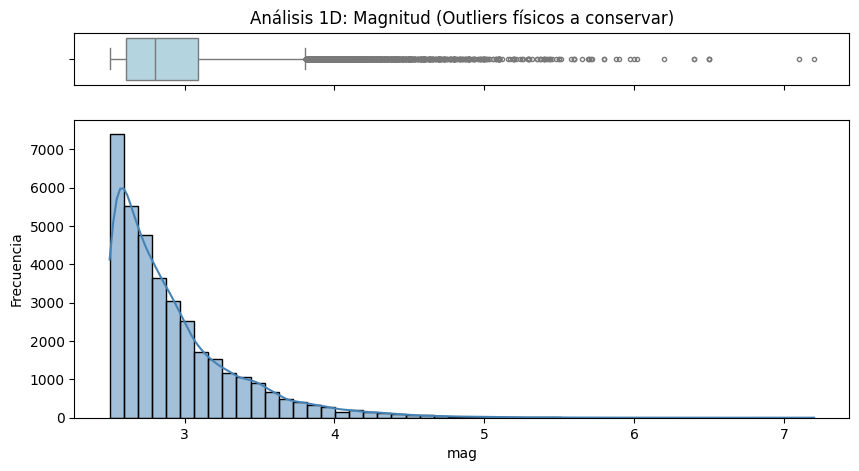

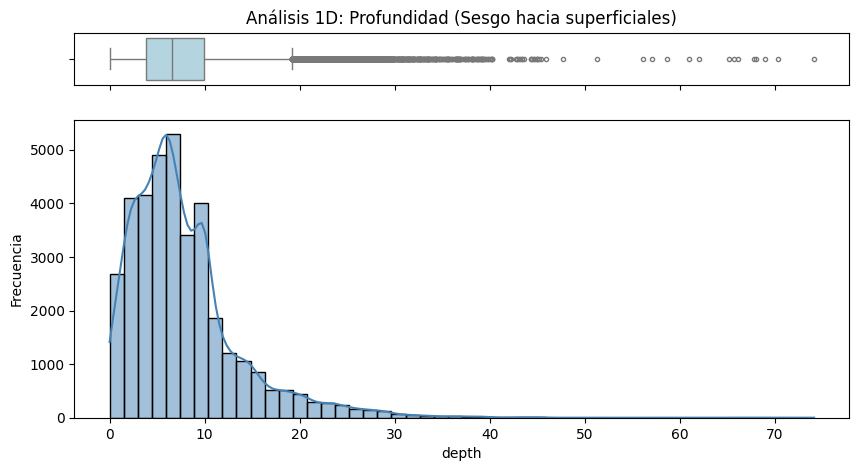

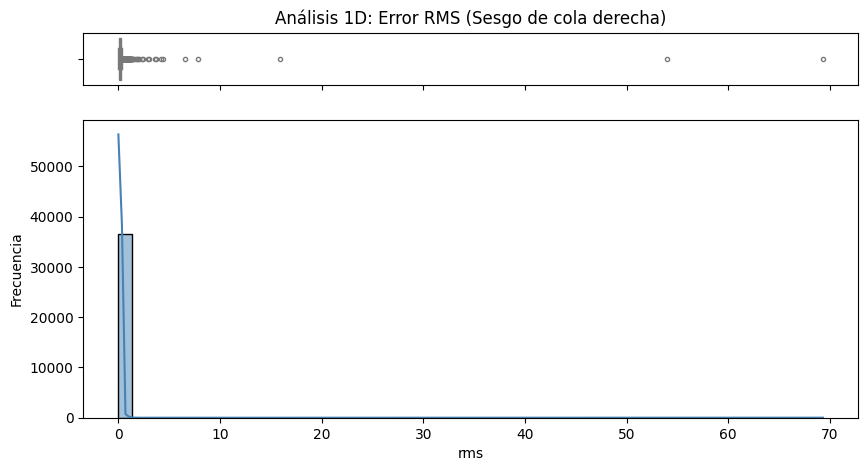

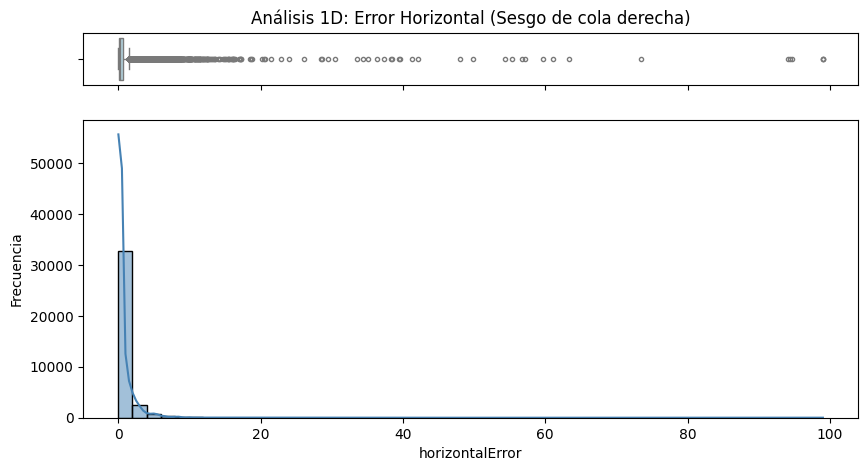

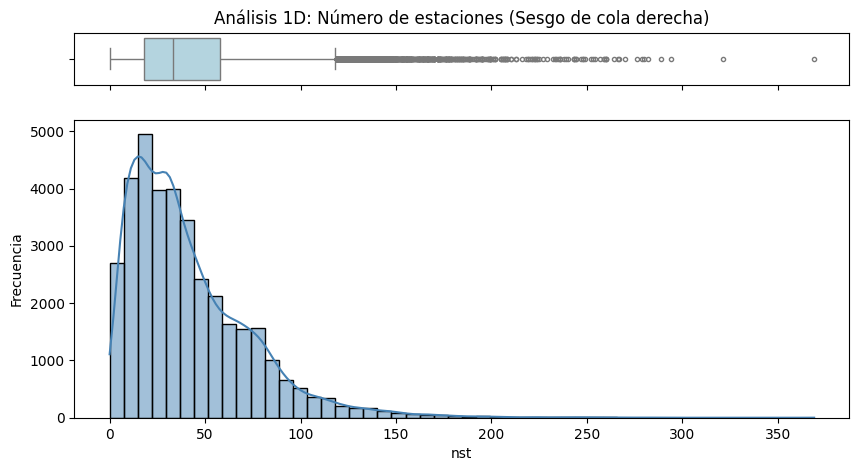

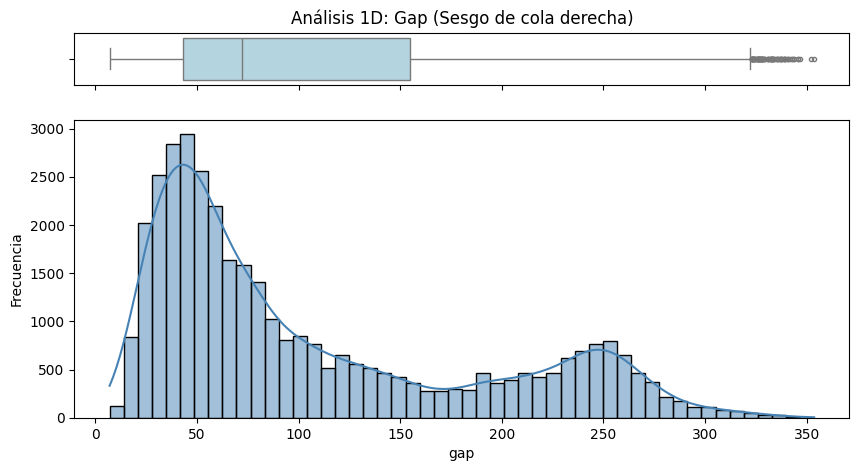

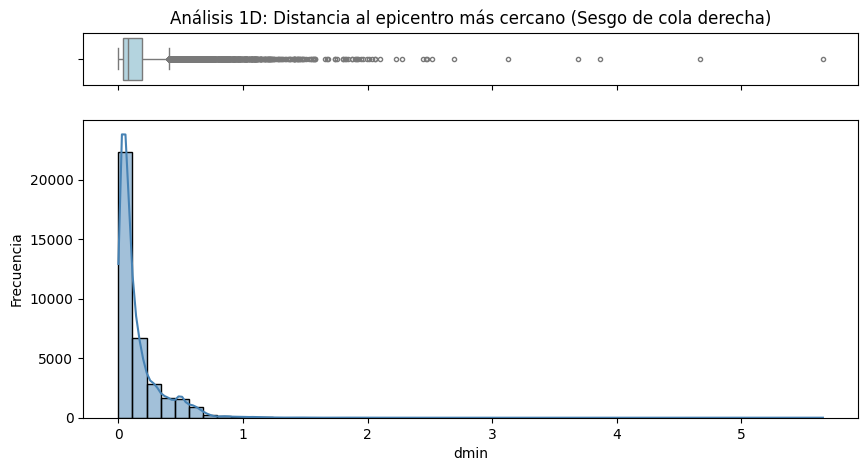

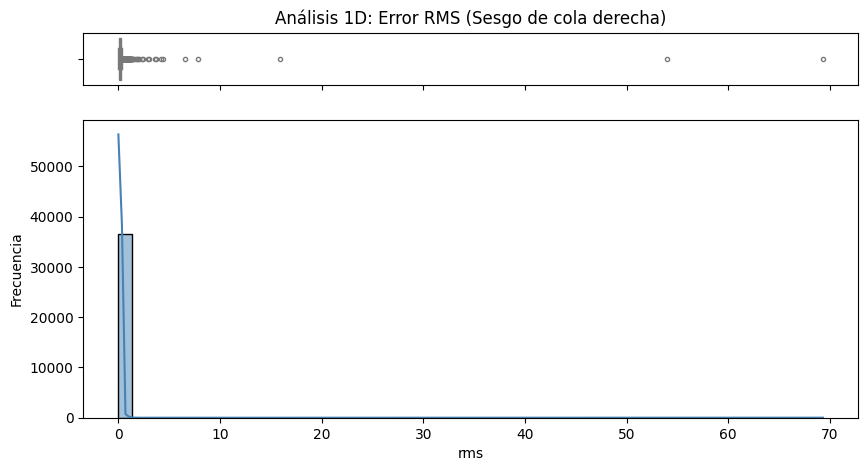

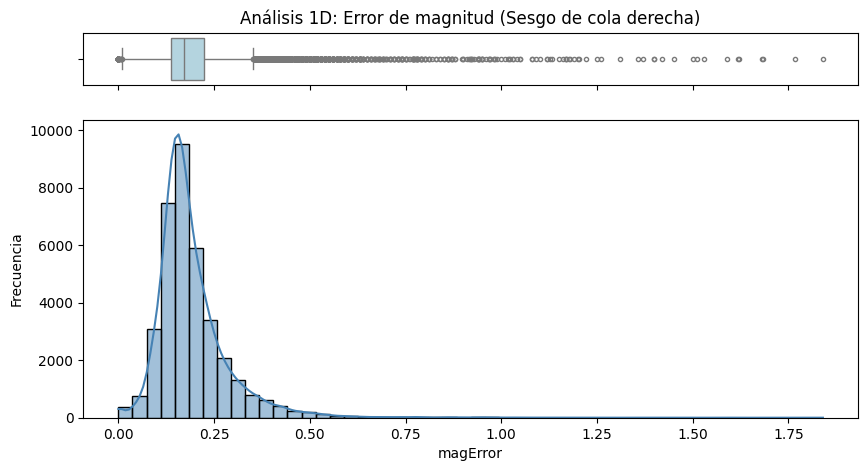

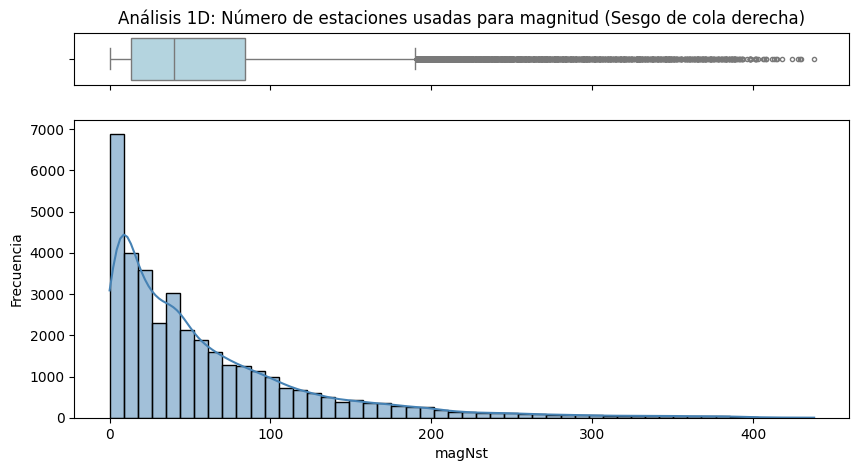

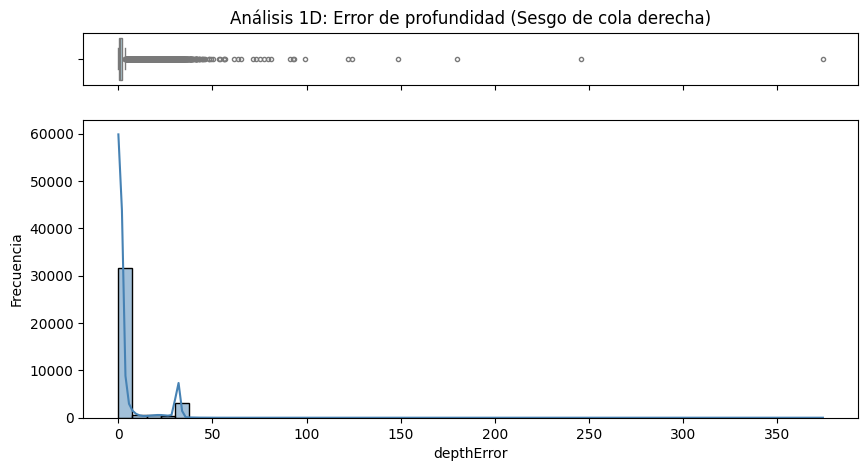

In [27]:
plot_1d_analysis(df_cal, 'mag', 'Análisis 1D: Magnitud (Outliers físicos a conservar)')
plot_1d_analysis(df_cal, 'depth', 'Análisis 1D: Profundidad (Sesgo hacia superficiales)')
plot_1d_analysis(df_cal, 'rms', 'Análisis 1D: Error RMS (Sesgo de cola derecha)')
plot_1d_analysis(df_cal, 'horizontalError', 'Análisis 1D: Error Horizontal (Sesgo de cola derecha)')
plot_1d_analysis(df_cal, 'nst', 'Análisis 1D: Número de estaciones (Sesgo de cola derecha)')
plot_1d_analysis(df_cal, 'gap', 'Análisis 1D: Gap (Sesgo de cola derecha)')
plot_1d_analysis(df_cal, 'dmin', 'Análisis 1D: Distancia al epicentro más cercano (Sesgo de cola derecha)')
plot_1d_analysis(df_cal, 'rms', 'Análisis 1D: Error RMS (Sesgo de cola derecha)')
plot_1d_analysis(df_cal, 'magError', 'Análisis 1D: Error de magnitud (Sesgo de cola derecha)')
plot_1d_analysis(df_cal, 'magNst', 'Análisis 1D: Número de estaciones usadas para magnitud (Sesgo de cola derecha)')
plot_1d_analysis(df_cal, 'depthError', 'Análisis 1D: Error de profundidad (Sesgo de cola derecha)')

In [28]:
outliers_magError = detect_outliers_mad(df_cal['magError'], threshold=3.5)
num_outliers = outliers_magError.sum()
print(f"Outliers 1D detectados en magError mediante MAD: {num_outliers}")

outliers_depthError = detect_outliers_mad(df_cal['depthError'], threshold=3.5)
num_outliers_depthError = outliers_depthError.sum()
print(f"Outliers 1D detectados en depthError mediante MAD: {num_outliers_depthError}")

outliers_horizontalError = detect_outliers_mad(df_cal['horizontalError'], threshold=3.5)
num_outliers_horizontalError = outliers_horizontalError.sum()
print(f"Outliers 1D detectados en horizontalError mediante MAD: {num_outliers_horizontalError}")

Outliers 1D detectados en magError mediante MAD: 1681
Outliers 1D detectados en depthError mediante MAD: 7461
Outliers 1D detectados en horizontalError mediante MAD: 7082


Para la detección de anomalías multivariantes, se descartó el uso de técnicas clásicas basadas en la matriz de covarianza, como la Distancia de Mahalanobis. Dado que Mahalanobis asume una distribución normal multivariante, su aplicación directa sobre variables sismológicas —las cuales presentan asimetrías severas y distribuciones de ley de potencias (como la relación de Gutenberg-Richter)— habría resultado en una elipse de confianza sesgada, clasificando erróneamente eventos físicos extremos (mainshocks) como ruido instrumental. En su lugar, se optó por algoritmos no paramétricos basados en partición espacial, como Isolation Forest, que no exigen supuestos de normalidad sobre las distribuciones subyacentes.

Conversiones de magnitud

In [29]:
df_cal["magType"].value_counts()

magType
ml     24151
md      9944
mw      1671
mlr      256
mc       251
mh       213
mb        28
mwr        6
ma         2
Ml         2
mww        1
Name: count, dtype: int64

In [30]:
df_cal['magType'] = df_cal['magType'].astype(str).str.lower()

# 1.2 Agrupar subtipos a sus clases principales
diccionario_reemplazo = {
    'mww': 'mw', 'mwr': 'mw',  # Derivados de Magnitud de Momento
    'mlr': 'ml',               # Derivado de Magnitud Local
    'mc': 'md'                 # Coda duration -> Magnitud de Duración
}
df_cal['magType'] = df_cal['magType'].replace(diccionario_reemplazo)

In [31]:
df_cal["magType"].value_counts()

magType
ml    24409
md    10195
mw     1678
mh      213
mb       28
ma        2
Name: count, dtype: int64

Veamos si hay algun sismo relevante (grande) que tener en cuenta en los que tienen un tipo de magnitud minoritaria.

In [32]:
df_cal.groupby('magType')['mag'].max()


magType
ma    3.0
mb    4.5
md    4.4
mh    5.4
ml    6.5
mw    7.2
Name: mag, dtype: float64

In [33]:
df_cal.groupby('magType')['mag'].min()

magType
ma    2.98
mb    2.50
md    2.50
mh    2.50
ml    2.50
mw    2.87
Name: mag, dtype: float64

Hacer conversiones de magnitud introduce sesgo, con lo que por una parte se va a realizar conversiones a mw, otro quedando sólo con los de tipo mw, y otro sólo quedando con ml.

Por otra parte, al ser pocos, y aún no hay un método muy consolidado para transformar de mh a mw, se eliminan estas observaciones, lo mismo con ma.

In [34]:
df_filtered = df_cal[~df_cal['magType'].isin(["mh","ma"])]
df_filtered["magType"].value_counts()

magType
ml    24409
md    10195
mw     1678
mb       28
Name: count, dtype: int64

In [35]:
def convert_to_mw(mag, mag_type):
    if mag_type == "mw":
        return mag
    elif mag_type == "mb":
        return 1.085 * mag - 0.45
    elif mag_type == "md":
        return 1.193 * mag - 0.52
    elif mag_type == "ml":
        return 0.906 * mag + 0.02
    else:
        return np.nan  # Si el tipo de magnitud no es reconocido, devuelve NaN, pero no debería ocurrir, pues ya limpiemos los tipos

In [36]:
df_filtered["mag_Mw"] = df_filtered.apply(lambda row: convert_to_mw(row['mag'], row['magType']), axis=1)

C:\Users\longj\AppData\Local\Temp\ipykernel_21996\3698325069.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["mag_Mw"] = df_filtered.apply(lambda row: convert_to_mw(row['mag'], row['magType']), axis=1)


In [37]:
df_filtered.describe()

,latitude,longitude,depth,mag,nst,gap,dmin,rms,horizontalError,depthError,magError,magNst,mag_Mw
count,36310.000000,36310.000000,36310.000000,36310.000000,36310.000000,36310.000000,36310.000000,36310.000000,36310.000000,36310.000000,36310.000000,36310.000000,36310.000000
mean,36.233092,-118.685961,7.814623,2.923481,41.936409,105.325293,0.151058,0.171669,0.802381,4.427486,0.193035,61.043211,2.752208
std,2.800782,2.773972,5.961189,0.428035,32.439546,80.412045,0.186887,0.318727,2.004661,9.811586,0.101057,66.148397,0.419745
min,32.000167,-124.998833,0.000000,2.500000,0.000000,7.000000,0.000000,0.000000,0.028000,0.000000,0.000000,0.000000,2.262500
25%,33.507542,-121.041958,3.840000,2.610000,18.000000,43.000000,0.038642,0.099000,0.160000,0.360000,0.138000,13.000000,2.474430
50%,36.032417,-117.974733,6.540000,2.800000,34.000000,71.700000,0.081080,0.150000,0.280000,0.640000,0.170490,40.000000,2.647400
75%,38.372950,-116.221425,9.984750,3.090000,58.000000,154.000000,0.185975,0.219475,0.710000,1.700000,0.223000,84.000000,2.910140
max,42.474333,-114.002800,74.160000,7.200000,369.000000,353.740000,4.665000,53.970000,99.000000,374.500000,1.840000,438.000000,7.200000


Uno de los principales desafíos al trabajar con datos instrumentales del USGS es la heterogeneidad de las métricas de magnitud reportadas (
M
L
,
m
b
,
M
d
,
M
w
M 
L
​
 ,m 
b
​
 ,M 
d
​
 ,M 
w
​
 
, entre otras), las cuales dependen de la red sensórica y de la naturaleza del evento. Dado que escalas empíricas como la Magnitud Local (
M
L
M 
L
​
 
) sufren fenómenos de saturación espectral para eventos de alta energía (generalmente 
M
>
6.5
M>6.5
), alimentar los modelos predictivos con un catálogo mixto introduciría sesgos sistemáticos insalvables.
Para subsanar este problema y garantizar la consistencia termodinámica de los datos, se procedió a la homogeneización del catálogo sísmico completo, convirtiendo todas las escalas a la Magnitud de Momento (
M
w
M 
w
​
 
). Esta escala, al estar directamente vinculada al momento sísmico (
M
0
M 
0
​
 
) y a propiedades físicas de la falla (área de ruptura y deslizamiento), no se satura y representa fielmente la energía liberada.
Desde la perspectiva de Ingeniería de Características (Feature Engineering), para evitar la pérdida de información respecto a la incertidumbre instrumental, se generó una variable indicadora booleana (is_converted_mag). Esta característica permite a los algoritmos de aprendizaje automático ponderar la incertidumbre residual introducida por las relaciones empíricas de conversión en aquellos eventos que no fueron medidos como 
M
w
M 
w
​
 
 en su origen.

In [38]:
df_cal_conv = df_filtered.drop(columns=['mag'])
df_cal_conv.describe()

,latitude,longitude,depth,nst,gap,dmin,rms,horizontalError,depthError,magError,magNst,mag_Mw
count,36310.000000,36310.000000,36310.000000,36310.000000,36310.000000,36310.000000,36310.000000,36310.000000,36310.000000,36310.000000,36310.000000,36310.000000
mean,36.233092,-118.685961,7.814623,41.936409,105.325293,0.151058,0.171669,0.802381,4.427486,0.193035,61.043211,2.752208
std,2.800782,2.773972,5.961189,32.439546,80.412045,0.186887,0.318727,2.004661,9.811586,0.101057,66.148397,0.419745
min,32.000167,-124.998833,0.000000,0.000000,7.000000,0.000000,0.000000,0.028000,0.000000,0.000000,0.000000,2.262500
25%,33.507542,-121.041958,3.840000,18.000000,43.000000,0.038642,0.099000,0.160000,0.360000,0.138000,13.000000,2.474430
50%,36.032417,-117.974733,6.540000,34.000000,71.700000,0.081080,0.150000,0.280000,0.640000,0.170490,40.000000,2.647400
75%,38.372950,-116.221425,9.984750,58.000000,154.000000,0.185975,0.219475,0.710000,1.700000,0.223000,84.000000,2.910140
max,42.474333,-114.002800,74.160000,369.000000,353.740000,4.665000,53.970000,99.000000,374.500000,1.840000,438.000000,7.200000


In [39]:
df_cal_conv['is_converted_mag'] = np.where(df_cal_conv['magType'] == "mw",
                                            0, 1)
df_cal_conv.head()

,time,latitude,longitude,depth,magType,nst,gap,dmin,rms,net,...,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource,mag_Mw,is_converted_mag
0,2000-01-01T03:58:39.500Z,34.801000,-116.287000,5.414000,ml,0.0,48.3,0.069212,0.163,ci,...,earthquake,0.199818,0.641,0.168296,187.0,reviewed,ci,ci,2.77424,1
1,2000-01-01T06:08:31.150Z,34.371667,-116.137333,2.946000,ml,38.0,56.0,0.116986,0.200,ci,...,earthquake,0.290000,0.540,0.191000,57.0,reviewed,ci,ci,2.41184,1
2,2000-01-02T15:49:40.650Z,38.038333,-118.696000,6.908404,md,51.0,107.0,0.225200,0.060,nc,...,earthquake,0.200000,6.580,0.180000,73.0,reviewed,nc,nc,3.19023,1
3,2000-01-02T16:35:49.290Z,38.039000,-118.697333,4.787000,md,50.0,107.0,0.225200,0.050,nc,...,earthquake,0.270000,4.180,0.250000,53.0,reviewed,nc,nc,2.53408,1
4,2000-01-02T17:58:32.820Z,34.309000,-116.072000,0.801000,ml,0.0,65.5,0.061025,0.172,ci,...,earthquake,0.196454,0.252,0.183687,178.0,reviewed,ci,ci,2.86484,1


In [40]:
df_cal_conv.drop(columns=['magType']).head()

,time,latitude,longitude,depth,nst,gap,dmin,rms,net,id,...,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource,mag_Mw,is_converted_mag
0,2000-01-01T03:58:39.500Z,34.801000,-116.287000,5.414000,0.0,48.3,0.069212,0.163,ci,ci9132027,...,earthquake,0.199818,0.641,0.168296,187.0,reviewed,ci,ci,2.77424,1
1,2000-01-01T06:08:31.150Z,34.371667,-116.137333,2.946000,38.0,56.0,0.116986,0.200,ci,ci9132039,...,earthquake,0.290000,0.540,0.191000,57.0,reviewed,ci,ci,2.41184,1
2,2000-01-02T15:49:40.650Z,38.038333,-118.696000,6.908404,51.0,107.0,0.225200,0.060,nc,nc21075275,...,earthquake,0.200000,6.580,0.180000,73.0,reviewed,nc,nc,3.19023,1
3,2000-01-02T16:35:49.290Z,38.039000,-118.697333,4.787000,50.0,107.0,0.225200,0.050,nc,nc21075281,...,earthquake,0.270000,4.180,0.250000,53.0,reviewed,nc,nc,2.53408,1
4,2000-01-02T17:58:32.820Z,34.309000,-116.072000,0.801000,0.0,65.5,0.061025,0.172,ci,ci9132273,...,earthquake,0.196454,0.252,0.183687,178.0,reviewed,ci,ci,2.86484,1


In [41]:
df_cal_ml = df_cal[df_cal['magType'] == 'ml']
df_cal_ml.describe()

,latitude,longitude,depth,mag,nst,gap,dmin,rms,horizontalError,depthError,magError,magNst
count,24409.000000,24409.000000,24409.000000,24409.000000,24409.000000,24409.000000,24409.000000,24409.000000,24409.000000,24409.000000,24409.000000,24409.000000
mean,35.385157,-117.359872,7.391882,2.942253,36.516490,111.158197,0.173394,0.198931,0.962878,5.914932,0.206816,67.012168
std,2.767271,1.977128,4.856149,0.396026,30.055244,83.058853,0.204078,0.376103,2.220114,11.242742,0.109760,76.113198
min,32.000167,-124.998833,0.000000,2.500000,0.000000,10.000000,0.000650,0.000000,0.060000,0.000000,0.000000,0.000000
25%,32.712667,-118.107667,3.900000,2.630000,15.000000,45.000000,0.046300,0.132400,0.200000,0.440000,0.145000,12.000000
50%,35.347167,-117.430333,6.730000,2.840000,29.000000,76.050000,0.093030,0.177000,0.340000,0.800000,0.180000,38.000000
75%,37.488600,-115.678333,9.970000,3.150000,49.000000,178.000000,0.219600,0.240000,1.030000,3.000000,0.240000,98.000000
max,42.474333,-114.002800,44.620000,6.500000,276.000000,353.740000,4.665000,53.970000,99.000000,374.500000,1.766000,438.000000


In [43]:
df_cal_mw = df_filtered[df_filtered["magType"] == "mw"]
df_cal_mw.describe()

,latitude,longitude,depth,mag,nst,gap,dmin,rms,horizontalError,depthError,magError,magNst,mag_Mw
count,1678.000000,1678.000000,1678.000000,1678.000000,1678.000000,1678.000000,1678.000000,1678.000000,1678.000000,1678.000000,1678.000000,1678.000000,1678.000000
mean,37.100017,-120.252416,8.476614,3.888087,76.921931,76.538802,0.091477,0.153472,0.341988,1.518129,0.186855,5.763409,3.888087
std,2.436414,2.851686,6.475048,0.532598,50.900940,68.388152,0.108226,0.097198,0.718937,5.373912,0.069167,7.310682,0.532598
min,32.025167,-124.985833,0.000000,2.870000,0.000000,7.000000,0.000901,0.030000,0.070000,0.000000,0.028000,0.000000,2.870000
25%,35.676625,-122.743583,4.055000,3.520000,42.000000,32.000000,0.027030,0.090000,0.120000,0.250000,0.147830,4.000000,3.520000
50%,37.263250,-121.002250,7.105000,3.770000,67.000000,49.000000,0.055240,0.140000,0.160000,0.380000,0.170802,4.000000,3.770000
75%,38.832667,-117.721542,10.134250,4.127500,94.000000,88.750000,0.111500,0.188950,0.280000,0.600000,0.203273,6.000000,4.127500
max,41.877200,-114.019000,35.620000,7.200000,369.000000,328.000000,0.842000,1.400000,20.161000,31.950000,0.777802,126.000000,7.200000


In [46]:
df_cal_conv['energia_julios'] = 10 ** (1.44 * df_cal_conv['mag_Mw'] + 5.24)

In [47]:
# ==========================================
# 1. CREACIÓN DE LA CUADRÍCULA ESPACIAL (GRID)
# ==========================================
# Redondeamos lat/lon para crear celdas (Ej: 1 grado x 1 grado)
df_cal_conv['lat_bin'] = df_cal_conv['latitude'].round(0)
df_cal_conv['lon_bin'] = df_cal_conv['longitude'].round(0)
df_cal_conv['cell_id'] = df_cal_conv['lat_bin'].astype(str) + "_" + df_cal_conv['lon_bin'].astype(str)
df_cal_conv["cell_id"].value_counts()

cell_id
32.0_-115.0    3851
33.0_-116.0    3763
36.0_-118.0    3604
39.0_-123.0    2157
38.0_-118.0    1882
               ... 
37.0_-123.0       2
41.0_-114.0       1
32.0_-114.0       1
35.0_-115.0       1
34.0_-123.0       1
Name: count, Length: 105, dtype: int64

In [48]:
def calcular_b_value(magnitudes, Mc=3.0, delta_M=0.1, n_minimo=30):
    """Fórmula de Máxima Verosimilitud (MLE) de Aki-Utsu"""
    mags_validas = magnitudes[magnitudes >= Mc]
    if len(mags_validas) < n_minimo:
        return np.nan # No hay datos suficientes para un cálculo fiable
    
    M_mean = np.mean(mags_validas)
    denominador = np.log(10) * (M_mean - (Mc - (delta_M / 2)))
    
    if denominador <= 0:
        return np.nan
    return 1 / denominador

# Asegurarnos de que los eventos están ordenados cronológicamente
df = df_cal_conv.sort_values(by=['cell_id', 'time'])

# Calcular el b-value usando los últimos 50 sismos de ESA celda
# min_periods=30 significa que empezará a dar valores a partir del sismo número 30
df['b_value_evento'] = (
    df.groupby('cell_id')['mag_Mw']
    .rolling(window=50, min_periods=30)
    .apply(lambda x: calcular_b_value(x, Mc=3.0, n_minimo=30))
    .reset_index(level=0, drop=True)
)

In [49]:
df['time'] = pd.to_datetime(df['time'])
df['date'] = df['time'].dt.floor('D')

In [50]:
# Agrupamos por celda y por fecha exacta (DÍA)
b_value_diario = df.groupby(['cell_id', 'date'])['b_value_evento'].last().reset_index()
b_value_diario.rename(columns={'b_value_evento': 'b_value_daily'}, inplace=True)

In [51]:
b_value_diario["b_value_daily"].value_counts()

b_value_daily
0.758092    1
0.923602    1
0.944696    1
Name: count, dtype: int64

In [52]:
# 1. Calculamos las estadísticas generales (como ya hacías)
daily_stats = df.groupby(['cell_id', 'date']).agg(
    eq_count=('mag_Mw', 'count'),
    energia_acumulada_diaria=('energia_julios', 'sum')
).reset_index()

# 2. Identificamos la fila del sismo más fuerte para cada celda y día
idx_max = df.groupby(['cell_id', 'date'])['mag_Mw'].idxmax()
main_events = df.loc[idx_max].copy()

# 3. Renombramos las columnas del sismo principal para no confundirlas
# Por ejemplo: 'depth' pasa a ser 'main_depth'
main_events = main_events.rename(columns={
    'mag_Mw': 'main_mag',
    'depth': 'main_depth',
    'latitude': 'main_lat',
    'longitude': 'main_lon'
})

# 4. Unimos todo en un solo DataFrame de "Panel"
# Ahora cada día tiene: cuántos sismos hubo Y los detalles del sismo más fuerte
final_daily = pd.merge(
    daily_stats, 
    main_events[['cell_id', 'date', 'main_mag', 'main_depth', 'main_lat', 'main_lon',
                 'magError', 'depthError', 'horizontalError', 'nst', 'gap', 'dmin', 'rms', 'magNst'
                 ,'is_converted_mag', 'lat_bin', 'lon_bin', 'locationSource', 'magSource',
                 'net', 'status', 'updated']], 
    on=['cell_id', 'date'], 
    how='left'
)

In [53]:
final_daily['date'] = pd.to_datetime(final_daily['date']).dt.date
final_daily.head(20)

,cell_id,date,eq_count,energia_acumulada_diaria,main_mag,main_depth,main_lat,main_lon,magError,depthError,...,rms,magNst,is_converted_mag,lat_bin,lon_bin,locationSource,magSource,net,status,updated
0,32.0_-114.0,2003-06-08,1,1.196868e+09,2.66531,5.975,32.015667,-114.357167,0.249000,31.610000,...,0.430,0.0,1,32.0,-114.0,ci,ci,ci,reviewed,2016-04-02T13:08:57.199Z
1,32.0_-115.0,2000-01-03,1,3.941232e+08,2.33030,5.998,32.433000,-115.331000,0.154754,30.158573,...,0.173,38.0,1,32.0,-115.0,ci,ci,ci,reviewed,2016-02-16T11:35:35.337Z
2,32.0_-115.0,2000-01-14,1,5.651826e+08,2.43902,5.963,32.092000,-114.952000,0.162733,24.011999,...,0.289,28.0,1,32.0,-115.0,ci,ci,ci,reviewed,2016-02-16T16:27:43.566Z
3,32.0_-115.0,2000-01-17,2,8.766331e+08,2.41184,5.977,32.480000,-115.451000,0.199406,30.463768,...,0.377,52.0,1,32.0,-115.0,ci,ci,ci,reviewed,2016-02-16T13:59:26.884Z
4,32.0_-115.0,2000-02-23,1,5.164754e+08,2.41184,5.963,32.307333,-115.160500,0.175000,31.610000,...,0.400,13.0,1,32.0,-115.0,ci,ci,ci,reviewed,2016-04-02T04:33:14.398Z
5,32.0_-115.0,2000-03-02,1,6.879195e+08,2.49829,5.954,32.180000,-114.967000,0.331504,31.062264,...,0.271,5.0,1,32.0,-115.0,ci,ci,ci,reviewed,2016-02-16T11:41:47.272Z
6,32.0_-115.0,2000-03-03,1,1.150449e+09,2.65338,5.963,32.104667,-114.988500,0.345075,31.610000,...,0.340,5.0,1,32.0,-115.0,ci,ci,ci,reviewed,2016-02-16T11:41:52.646Z
7,32.0_-115.0,2000-03-25,1,2.082357e+09,2.83233,5.963,32.172000,-115.068500,0.237276,31.610000,...,0.380,8.0,1,32.0,-115.0,ci,ci,ci,reviewed,2016-02-16T16:34:26.041Z
8,32.0_-115.0,2000-04-14,1,7.406387e+08,2.52056,5.997,32.416000,-115.312667,0.342000,31.610000,...,0.290,17.0,1,32.0,-115.0,ci,ci,ci,reviewed,2016-04-02T07:53:48.908Z
9,32.0_-115.0,2000-04-15,1,4.719657e+08,2.38466,5.997,32.399500,-115.309667,0.278000,31.610000,...,0.260,14.0,1,32.0,-115.0,ci,ci,ci,reviewed,2016-04-02T01:27:21.198Z


In [54]:
b_value_diario = b_value_diario.fillna(1.0)
b_value_diario["date"] = pd.to_datetime(b_value_diario["date"]).dt.date
b_value_diario.head(20)


,cell_id,date,b_value_daily
0,32.0_-114.0,2003-06-08,1.0
1,32.0_-115.0,2000-01-03,1.0
2,32.0_-115.0,2000-01-14,1.0
3,32.0_-115.0,2000-01-17,1.0
4,32.0_-115.0,2000-02-23,1.0
5,32.0_-115.0,2000-03-02,1.0
6,32.0_-115.0,2000-03-03,1.0
7,32.0_-115.0,2000-03-25,1.0
8,32.0_-115.0,2000-04-14,1.0
9,32.0_-115.0,2000-04-15,1.0


In [55]:
final_daily = pd.merge(final_daily, b_value_diario, on=['cell_id', 'date'], how='left')


In [56]:
final_daily[final_daily["eq_count"] == 0][["cell_id", "date", "eq_count", "b_value_daily"]].head(20)

,cell_id,date,eq_count,b_value_daily


In [57]:
# ==========================================
# 4. RELLENAR LOS DÍAS VACÍOS (ZEROS)
# ==========================================
# Creamos un MultiIndex con todas las combinaciones posibles de Fechas y Celdas
all_dates = pd.date_range(start=daily_stats['date'].min(), end=daily_stats['date'].max(), freq='D')
all_dates = pd.to_datetime(all_dates).date
all_cells = daily_stats['cell_id'].unique()
full_index = pd.MultiIndex.from_product([all_cells, all_dates], names=['cell_id', 'date'])

# Reindexamos y rellenamos los nulos (días sin sismos) con ceros
panel_df = final_daily.set_index(['cell_id', 'date']).reindex(full_index).reset_index()

In [58]:
panel_df = final_daily.set_index(['cell_id', 'date']).reindex(full_index).reset_index()

In [59]:
panel_df.head(20)

,cell_id,date,eq_count,energia_acumulada_diaria,main_mag,main_depth,main_lat,main_lon,magError,depthError,...,magNst,is_converted_mag,lat_bin,lon_bin,locationSource,magSource,net,status,updated,b_value_daily
0,32.0_-114.0,2000-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,32.0_-114.0,2000-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,32.0_-114.0,2000-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,32.0_-114.0,2000-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,32.0_-114.0,2000-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,32.0_-114.0,2000-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,32.0_-114.0,2000-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,32.0_-114.0,2000-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,32.0_-114.0,2000-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,32.0_-114.0,2000-01-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [60]:
columnas_cero = ['eq_count', 'main_mag', 'main_depth', 'main_lat', 'main_lon',
                 'magError', 'depthError', 'horizontalError', 'nst', 'gap',
                    'dmin', 'rms', 'magNst', 'is_converted_mag', 'lat_bin', 'lon_bin']
panel_df[columnas_cero] = panel_df[columnas_cero].fillna(0)
panel_df["b_value_daily"] = panel_df["b_value_daily"].fillna(1.0)
panel_df["locationSource"] = panel_df["locationSource"].fillna("empty")
panel_df["magSource"] = panel_df["magSource"].fillna("empty")
panel_df["net"] = panel_df["net"].fillna("empty")
panel_df["status"] = panel_df["status"].fillna("empty")
panel_df["updated"] = panel_df["updated"].fillna("empty")
panel_df["is_converted_mag"] = panel_df["is_converted_mag"].fillna(0)
panel_df['energia_acumulada_diaria'] = panel_df['energia_acumulada_diaria'].fillna(0)
panel_df.isnull().sum()

cell_id                     0
date                        0
eq_count                    0
energia_acumulada_diaria    0
main_mag                    0
main_depth                  0
main_lat                    0
main_lon                    0
magError                    0
depthError                  0
horizontalError             0
nst                         0
gap                         0
dmin                        0
rms                         0
magNst                      0
is_converted_mag            0
lat_bin                     0
lon_bin                     0
locationSource              0
magSource                   0
net                         0
status                      0
updated                     0
b_value_daily               0
dtype: int64

In [61]:
panel_df = panel_df.sort_values(['cell_id', 'date'])

In [62]:
grouped = panel_df.groupby('cell_id')

# Lags directos (Día anterior t-1)
panel_df['lag1_mag_max'] = grouped['main_mag'].shift(1)
panel_df['lag1_eq_count'] = grouped['eq_count'].shift(1)
panel_df['energia_lag1'] = grouped['energia_acumulada_diaria'].shift(1)

# Ventanas Móviles (Rolling Windows) de los últimos 7 y 30 días (sin contar el día actual para no hacer Data Leakage)
# Usamos shift(1) para que la ventana evalúe HASTA ayer.
panel_df['roll7_eq_count'] = grouped['eq_count'].transform(lambda x: x.shift(1).rolling(7).sum())
panel_df['roll30_eq_count'] = grouped['eq_count'].transform(lambda x: x.shift(1).rolling(30).sum())
panel_df['roll7_mag_max'] = grouped['main_mag'].transform(lambda x: x.shift(1).rolling(7).max())
panel_df['roll30_mag_max'] = grouped['main_mag'].transform(lambda x: x.shift(1).rolling(30).max())
panel_df['roll7_energia'] = grouped['energia_acumulada_diaria'].transform(lambda x: x.shift(1).rolling(7).sum())
panel_df['roll30_energia'] = grouped['energia_acumulada_diaria'].transform(lambda x: x.shift(1).rolling(30).sum())


In [63]:
panel_df['date'] = pd.to_datetime(panel_df['date'])

# 2. Creamos la columna temporal con las fechas de sismos
panel_df['temp_eq_date'] = panel_df['date'].where(panel_df['eq_count'] > 0)
# 3. EL TRUCO: Aplicamos ffill() y shift() DENTRO del groupby
panel_df['last_eq_date'] = panel_df.groupby('cell_id')['temp_eq_date'].transform(lambda x: x.ffill().shift(1))
panel_df['days_since_last_eq'] = (panel_df['date'] - panel_df['last_eq_date']).dt.days  #.fillna(999).astype(int)

In [64]:
panel_df["days_since_last_eq"].describe()

count    846090.000000
mean        505.930461
std        1085.493642
min           1.000000
25%          21.000000
50%          90.000000
75%         384.000000
max        8355.000000
Name: days_since_last_eq, dtype: float64

Aquí se puede incorporar por ejemplo de datos desde 1900 hasta 2000 para rellenar los dias transcurridos desde el ultimo terremoto, y si aun es faltante, rellenar con 9999.

In [65]:
panel_look_back = pd.read_csv('panel_look_back.csv')
panel_look_back["date"] = pd.to_datetime(panel_look_back["date"]).dt.date
panel_look_back["date"].describe()

count         335984
unique          3652
top       1999-12-31
freq              92
Name: date, dtype: object

In [66]:
df_combinado = pd.concat([panel_look_back[['cell_id', 'date', 'eq_count']], panel_df])
df_combinado['date'] = pd.to_datetime(df_combinado['date'])

In [67]:
df_combinado = df_combinado.sort_values(['cell_id', 'date'])

df_combinado['temp_eq_date'] = df_combinado['date'].where(df_combinado['eq_count'] > 0)
df_combinado['last_eq_date'] = df_combinado.groupby('cell_id')['temp_eq_date'].transform(lambda x: x.ffill().shift(1))

# 4. Calculamos los días transcurridos
df_combinado['days_since_last_eq'] = (df_combinado['date'] - df_combinado['last_eq_date']).dt.days

In [68]:
df_combinado['days_since_last_eq'].describe()


count    1.191180e+06
mean     4.982667e+02
std      1.063352e+03
min      1.000000e+00
25%      2.000000e+01
50%      9.200000e+01
75%      4.030000e+02
max      8.631000e+03
Name: days_since_last_eq, dtype: float64

In [69]:
fecha_inicio_estudio = '2000-01-01'

# Filtramos para quedarnos solo con las fechas que te interesan
panel_df1 = df_combinado[df_combinado['date'] >= fecha_inicio_estudio].copy()

# Eliminamos la columna temporal
panel_df1.drop(columns=['temp_eq_date'], inplace=True)

In [70]:
#Limpieza final: Si incluso mirando años atrás sigue siendo NaN, 
# significa que esa celda es históricamente inactiva. Ahí sí usamos el 9999.
panel_df1['days_since_last_eq'] = panel_df1['days_since_last_eq'].fillna(9999).astype(int)
panel_df1["days_since_last_eq"].describe()

count    920430.000000
mean        926.425137
std        2113.764307
min           1.000000
25%          24.000000
50%         113.000000
75%         570.000000
max        9999.000000
Name: days_since_last_eq, dtype: float64

In [71]:
panel_df['days_since_last_eq'] = panel_df1["days_since_last_eq"]

In [72]:
panel_df["days_since_last_eq"].describe()

count    920430.000000
mean        926.425137
std        2113.764307
min           1.000000
25%          24.000000
50%         113.000000
75%         570.000000
max        9999.000000
Name: days_since_last_eq, dtype: float64

In [73]:
panel_df = panel_df.drop(columns=['last_eq_date'])

In [74]:
panel_df['TARGET_mag_max_next_7d'] = grouped['main_mag'].transform(lambda x: x.rolling(7).max().shift(-7))

# Target Clasificación: ¿Habrá un sismo mayor a 4.5 en los próximos 7 días?
panel_df['TARGET_occurrence_M4.5'] = (panel_df['TARGET_mag_max_next_7d'] >= 4.5).astype(int)
panel_df['TARGET_occurrence_M3.0'] = (panel_df['TARGET_mag_max_next_7d'] >= 3.0).astype(int)

In [75]:
l = panel_df["main_mag"] > 4.5
cont  = 0
for i in range(len(panel_df)):
    if l[i] == True:
        cont += 1
print(f"Total de filas con main_mag > 4.5: {cont}")

Total de filas con main_mag > 4.5: 177


In [76]:
l = panel_df["main_mag"] > 3.5
cont  = 0
for i in range(len(panel_df)):
    if l[i] == True:
        cont += 1
print(f"Total de filas con main_mag > 3.5: {cont}")

l = panel_df["main_mag"] > 3
cont  = 0
for i in range(len(panel_df)):
    if l[i] == True:
        cont += 1
print(f"Total de filas con main_mag > 3: {cont}")

Total de filas con main_mag > 3.5: 1566
Total de filas con main_mag > 3: 4444


In [77]:
panel_df.isnull().sum()

cell_id                          0
date                             0
eq_count                         0
energia_acumulada_diaria         0
main_mag                         0
main_depth                       0
main_lat                         0
main_lon                         0
magError                         0
depthError                       0
horizontalError                  0
nst                              0
gap                              0
dmin                             0
rms                              0
magNst                           0
is_converted_mag                 0
lat_bin                          0
lon_bin                          0
locationSource                   0
magSource                        0
net                              0
status                           0
updated                          0
b_value_daily                    0
lag1_mag_max                   105
lag1_eq_count                  105
energia_lag1                   105
roll7_eq_count      

In [78]:
panel_df.drop("temp_eq_date", axis=1, inplace=True)

In [79]:
panel_df_final = panel_df.dropna().copy()
panel_df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 916545 entries, 30 to 920422
Data columns (total 38 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   cell_id                   916545 non-null  object        
 1   date                      916545 non-null  datetime64[ns]
 2   eq_count                  916545 non-null  float64       
 3   energia_acumulada_diaria  916545 non-null  float64       
 4   main_mag                  916545 non-null  float64       
 5   main_depth                916545 non-null  float64       
 6   main_lat                  916545 non-null  float64       
 7   main_lon                  916545 non-null  float64       
 8   magError                  916545 non-null  float64       
 9   depthError                916545 non-null  float64       
 10  horizontalError           916545 non-null  float64       
 11  nst                       916545 non-null  float64       
 12  gap   

In [80]:
panel_df_final.tail()

,cell_id,date,eq_count,energia_acumulada_diaria,main_mag,main_depth,main_lat,main_lon,magError,depthError,...,roll7_eq_count,roll30_eq_count,roll7_mag_max,roll30_mag_max,roll7_energia,roll30_energia,days_since_last_eq,TARGET_mag_max_next_7d,TARGET_occurrence_M4.5,TARGET_occurrence_M3.0
920418,42.0_-125.0,2023-12-20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,264,0.0,0,0
920419,42.0_-125.0,2023-12-21,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,265,0.0,0,0
920420,42.0_-125.0,2023-12-22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,266,0.0,0,0
920421,42.0_-125.0,2023-12-23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,267,0.0,0,0
920422,42.0_-125.0,2023-12-24,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,268,0.0,0,0


In [81]:
panel_df_final["days_since_last_eq"].describe()

count    916545.000000
mean        924.246668
std        2108.323831
min           1.000000
25%          24.000000
50%         114.000000
75%         570.000000
max        9999.000000
Name: days_since_last_eq, dtype: float64

In [82]:
!pip install pyarrow

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\longj\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [83]:
panel_df_final.to_csv('datos_mw_conv_final.csv', index=False)

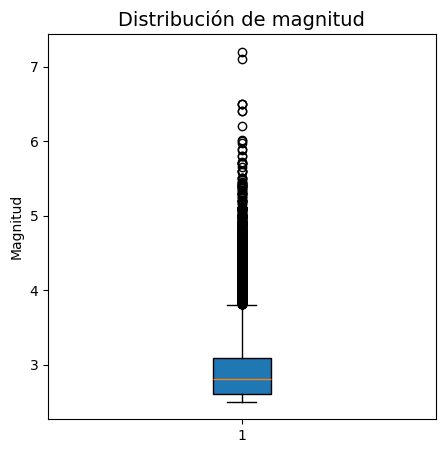

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))

plt.boxplot(
    df_california_total['mag'],
    patch_artist=True
)

plt.title('Distribución de magnitud', fontsize=14)
plt.ylabel('Magnitud')

plt.show()

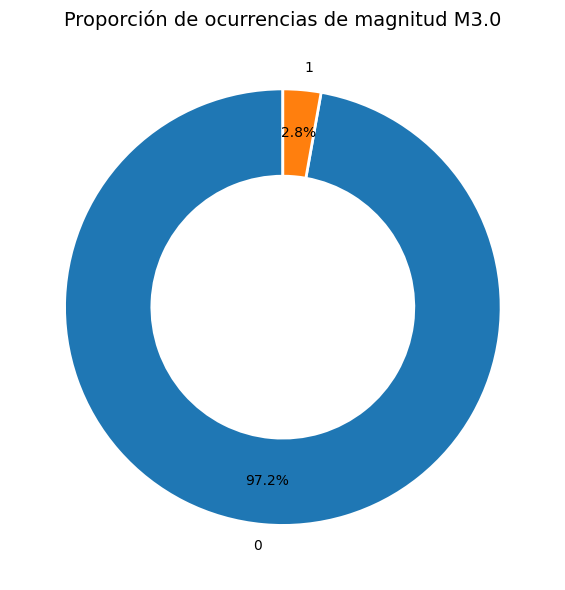

In [88]:
conteo = panel_df_final['TARGET_occurrence_M3.0'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    conteo,
    labels=conteo.index,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.8,
    wedgeprops={
        'width':0.4,      # agujero central
        'edgecolor':'white',
        'linewidth':2
    }
)

plt.title('Proporción de ocurrencias de magnitud M3.0', fontsize=14)

plt.tight_layout()
plt.show()